# TITLE: Building Simple and Multiple Linear Rgeression Models with Regression Line and Residual Plots
## OBJECTIVES:
1. Build and intepret a simple linear regression model and visuallize the regression line and residual plot.
2. Extending the same idea tp miltiple linear regression with several variables and evaluate it using residual analysis.

In [8]:
import numpy as np
import pandas as pd 
data={
    "Advertising": [10,12,15,18,20,22,25,28,30,35],
    "Sales": [25,28,30,35,37,40,44,48,50,58]
}
df=pd.DataFrame(data)
df

,Advertising,Sales
0,10,25
1,12,28
2,15,30
3,18,35
4,20,37
5,22,40
6,25,44
7,28,48
8,30,50
9,35,58


In [12]:
import numpy as np
x=df[["Advertising"]]
y=df["Sales"]

In [13]:
from sklearn.linear_model import LinearRegression

slr=LinearRegression()
slr.fit(x,y)
print("Intercept(b0);",slr.intercept_)
print("Slope(b1):",slr.coef_[0])

Intercept(b0); 11.460492778249797
Slope(b1): 1.3041631265930327


In [15]:
df["Predicted_sales"]=slr.predict(x)
df

,Advertising,Sales,Predicted_sales
0,10,25,24.502124
1,12,28,27.110450
2,15,30,31.022940
3,18,35,34.935429
4,20,37,37.543755
5,22,40,40.152082
6,25,44,44.064571
7,28,48,47.977060
8,30,50,50.585387
9,35,58,57.106202


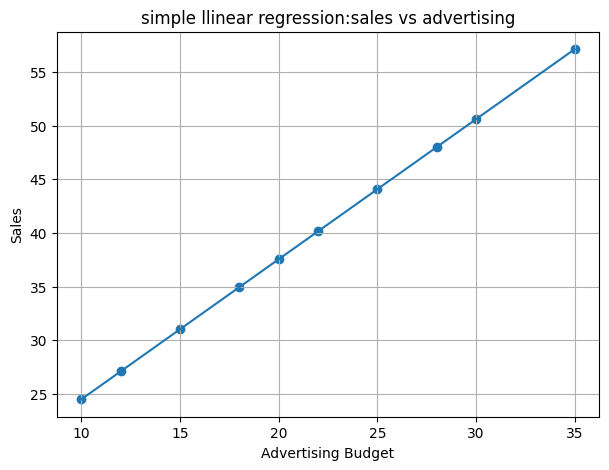

In [26]:
#visualizing
import matplotlib.pyplot as plt
plt.figure(figsize=(7,5))
plt.scatter(df["Advertising"],df["Predicted_sales"])
plt.plot(df["Advertising"],df["Predicted_sales"])
plt.title("simple llinear regression:sales vs advertising")
plt.xlabel("Advertising Budget")


plt.ylabel("Sales")
plt.grid(True)
plt.show()

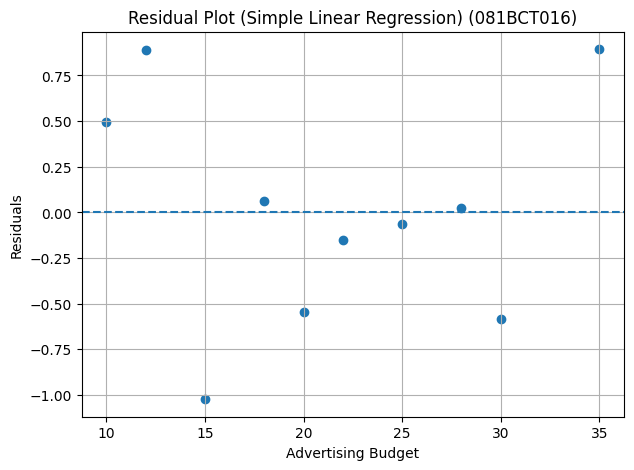

In [29]:
df["Residuals"]= df["Sales"] - df["Predicted_sales"] 
plt.figure(figsize=(7,5)) 
plt.scatter(df ["Advertising"], df["Residuals"]) 
plt.axhline(y=0, linestyle='--') 
plt.title("Residual Plot (Simple Linear Regression) (081BCT016)") 
plt.xlabel("Advertising Budget") 
plt.ylabel("Residuals") 
plt.grid(True) 
plt.show()

##  Multiple Linear Regression (Several Input Features)
### Problem Statement 
## predicting Sales Using: 
1. Advertsing Budget
2. Product Price
3. Number of SalesPersons

In [31]:
#Create a multivariable dataset
data2={
    "Advertising": [10,12,15,18,20,22,25,28,30,35],
    "Price":[110,105,108,100,98,95,92,90,88,85],
    "Salespeople":[2,2,3,3,3,4,4,4,5,5],
    "Sales": [25,28,30,35,37,40,44,48,50,58]
}
df2=pd.DataFrame(data2)
df2

,Advertising,Price,Salespeople,Sales
0,10,110,2,25
1,12,105,2,28
2,15,108,3,30
3,18,100,3,35
4,20,98,3,37
5,22,95,4,40
6,25,92,4,44
7,28,90,4,48
8,30,88,5,50
9,35,85,5,58


In [33]:
#preparing x and y
x_multi=df2[["Advertising","Price","Salespeople"]]
y_multi=df2["Sales"]

In [37]:
mlr = LinearRegression()
mlr.fit(x_multi,y_multi)
print("Intercept(b0):",mlr.intercept_)
print("Coefficient(b1,b2,b3:)",mlr.coef_)

Intercept(b0): 19.666066730324072
Coefficient(b1,b2,b3:) [ 1.38269298 -0.06179115 -1.11258424]


In [39]:
df2["Predicted_sales"]=mlr.predict(x_multi)
df2["Residuals"]=df2["Sales"]-df2["Predicted_sales"]
df2

,Advertising,Price,Salespeople,Sales,Predicted_sales,Residuals
0,10,110,2,25,24.470801,0.529199
1,12,105,2,28,27.545143,0.454857
2,15,108,3,30,30.395264,-0.395264
3,18,100,3,35,35.037672,-0.037672
4,20,98,3,37,37.926641,-0.926641
5,22,95,4,40,39.764816,0.235184
6,25,92,4,44,44.098268,-0.098268
7,28,90,4,48,48.369929,-0.369929
8,30,88,5,50,50.146313,-0.146313
9,35,85,5,58,57.245152,0.754848


In [43]:
from sklearn.metrics import r2_score,mean_squared_error
r2=r2_score(y_multi,df2["Predicted_sales"])
mse=mean_squared_error(y_multi,df2["Predicted_sales"])
print("r^2 score",r2)
print("MSE:",mse)

r^2 score 0.9977140054359459
MSE: 0.22962815395923702


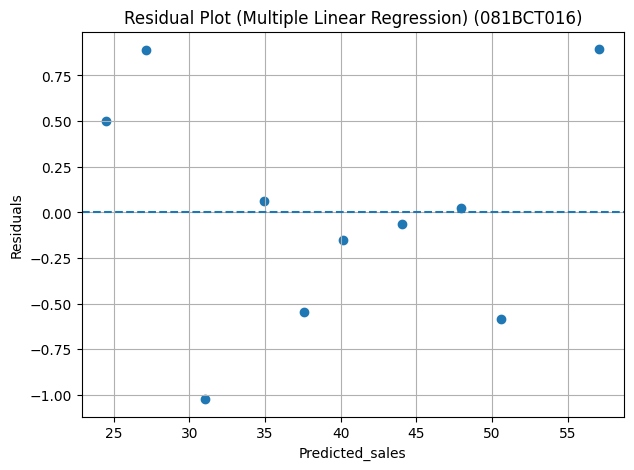

In [44]:
plt.figure(figsize=(7,5)) 
plt.scatter(df ["Predicted_sales"], df["Residuals"]) 
plt.axhline(y=0, linestyle='--') 
plt.title("Residual Plot (Multiple Linear Regression) (081BCT016)") 
plt.xlabel("Predicted_sales") 
plt.ylabel("Residuals") 
plt.grid(True) 
plt.show()